In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/train.csv")
print(df.shape)
df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:

print("=== Shape ===")
print(df.shape)

print("\n=== Column Info (data types + missing counts) ===")
df.info()

print("\n=== Missing Values Per Column ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
df.describe()

=== Shape ===
(891, 12)

=== Column Info (data types + missing counts) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

=== Missing Values Per Column ===
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
P

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Data Observations

| Column | Missing | Decision |
|--------|---------|----------|
| Age | 177 (20%) | Impute with median |
| Cabin | 687 (77%) | Drop — too sparse |
| Embarked | 2 (<1%) | Fill with mode |

**Key insight:** Survived = 0 means died, 1 means survived.  
Only ~38% survived — the dataset is imbalanced.

In [3]:
#WHY: We work on a copy to preserve the original raw data.
df_clean = df.copy()


#-WHY: Dropping 177 rows would lose 20% of our dataset — too costly
# WHY median over mean: Age has outliers (very old passengers).
median_age = df_clean['Age'].median()
print(f"Median Age used for imputation: {median_age}")
df_clean['Age'].fillna(median_age, inplace=True)

# ksWHY: 77% missing means we can't reliably impute this.
df_clean.drop(columns=['Cabin'], inplace=True)

# WHY: Just 2 rows missing. Safe to fill with mode (most common value).
mode_embarked = df_clean['Embarked'].mode()[0]
print(f"Mode Embarked used for imputation: {mode_embarked}")
df_clean['Embarked'].fillna(mode_embarked, inplace=True)


df_clean.drop(columns=['Name', 'Ticket', 'PassengerId'], inplace=True)

print("\n=== Missing Values After Cleaning ===")
print(df_clean.isnull().sum())
print(f"\nFinal shape: {df_clean.shape}")
print(f"Columns remaining: {list(df_clean.columns)}")



Median Age used for imputation: 28.0
Mode Embarked used for imputation: S

=== Missing Values After Cleaning ===
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Final shape: (891, 8)
Columns remaining: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


C:\Users\manvi\AppData\Local\Temp\ipykernel_24876\2849728055.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Age'].fillna(median_age, inplace=True)
C:\Users\manvi\AppData\Local\Temp\ipykernel_24876\2849728055.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

## Exploratory Analysis
We explore survival patterns across key variables.  
Central question: **Who survived, and why?**

In [4]:
# Question 1: What was the overall survival rate?
survival_counts = df_clean['Survived'].value_counts()
survival_rate = df_clean['Survived'].mean() * 100

print(f"Died: {survival_counts[0]} passengers")
print(f"Survived: {survival_counts[1]} passengers")
print(f"Overall survival rate: {survival_rate:.1f}%")

Died: 549 passengers
Survived: 342 passengers
Overall survival rate: 38.4%


In [5]:
# Question 2: Did gender affect survival?
# The "women and children first" protocol suggests it should
sex_survival = df_clean.groupby('Sex')['Survived'].mean() * 100
print("Survival rate by Sex:")
print(sex_survival.round(1))

# WHY .mean() on a 0/1 column: mean of binary = proportion = rate
# e.g. [1,0,1,1,0].mean() = 3/5 = 0.6 = 60% survival rate

Survival rate by Sex:
Sex
female    74.2
male      18.9
Name: Survived, dtype: float64


In [6]:
# Question 3: Did wealth/class matter?
class_survival = df_clean.groupby('Pclass')['Survived'].mean() * 100
print("Survival rate by Passenger Class:")
print(class_survival.round(1))
print("\n1=First Class (wealthy), 2=Second Class, 3=Third Class (poor)")

Survival rate by Passenger Class:
Pclass
1    63.0
2    47.3
3    24.2
Name: Survived, dtype: float64

1=First Class (wealthy), 2=Second Class, 3=Third Class (poor)


In [7]:
# Question 4: Were children more likely to survive?
# We create age bins to group passengers
df_clean['AgeGroup'] = pd.cut(df_clean['Age'], 
                               bins=[0, 12, 18, 35, 60, 100],
                               labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior'])

age_survival = df_clean.groupby('AgeGroup')['Survived'].mean() * 100
print("Survival rate by Age Group:")
print(age_survival.round(1))

Survival rate by Age Group:
AgeGroup
Child         58.0
Teen          42.9
YoungAdult    35.3
Adult         40.0
Senior        22.7
Name: Survived, dtype: float64


C:\Users\manvi\AppData\Local\Temp\ipykernel_24876\828677594.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df_clean.groupby('AgeGroup')['Survived'].mean() * 100


In [8]:
# Question 5: Does the class + gender combination tell a richer story?
# This is a pivot table — rows=Pclass, columns=Sex, values=survival rate
pivot = df_clean.pivot_table(values='Survived', 
                              index='Pclass', 
                              columns='Sex', 
                              aggfunc='mean') * 100
print("Survival Rate (%) by Class and Sex:")
print(pivot.round(1))

Survival Rate (%) by Class and Sex:
Sex     female  male
Pclass              
1         96.8  36.9
2         92.1  15.7
3         50.0  13.5


## Visualizations
Charts that tell the survival story visually.

C:\Users\manvi\AppData\Local\Temp\ipykernel_24876\1557340033.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Sex', y='Survived',
C:\Users\manvi\AppData\Local\Temp\ipykernel_24876\1557340033.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Pclass', y='Survived',


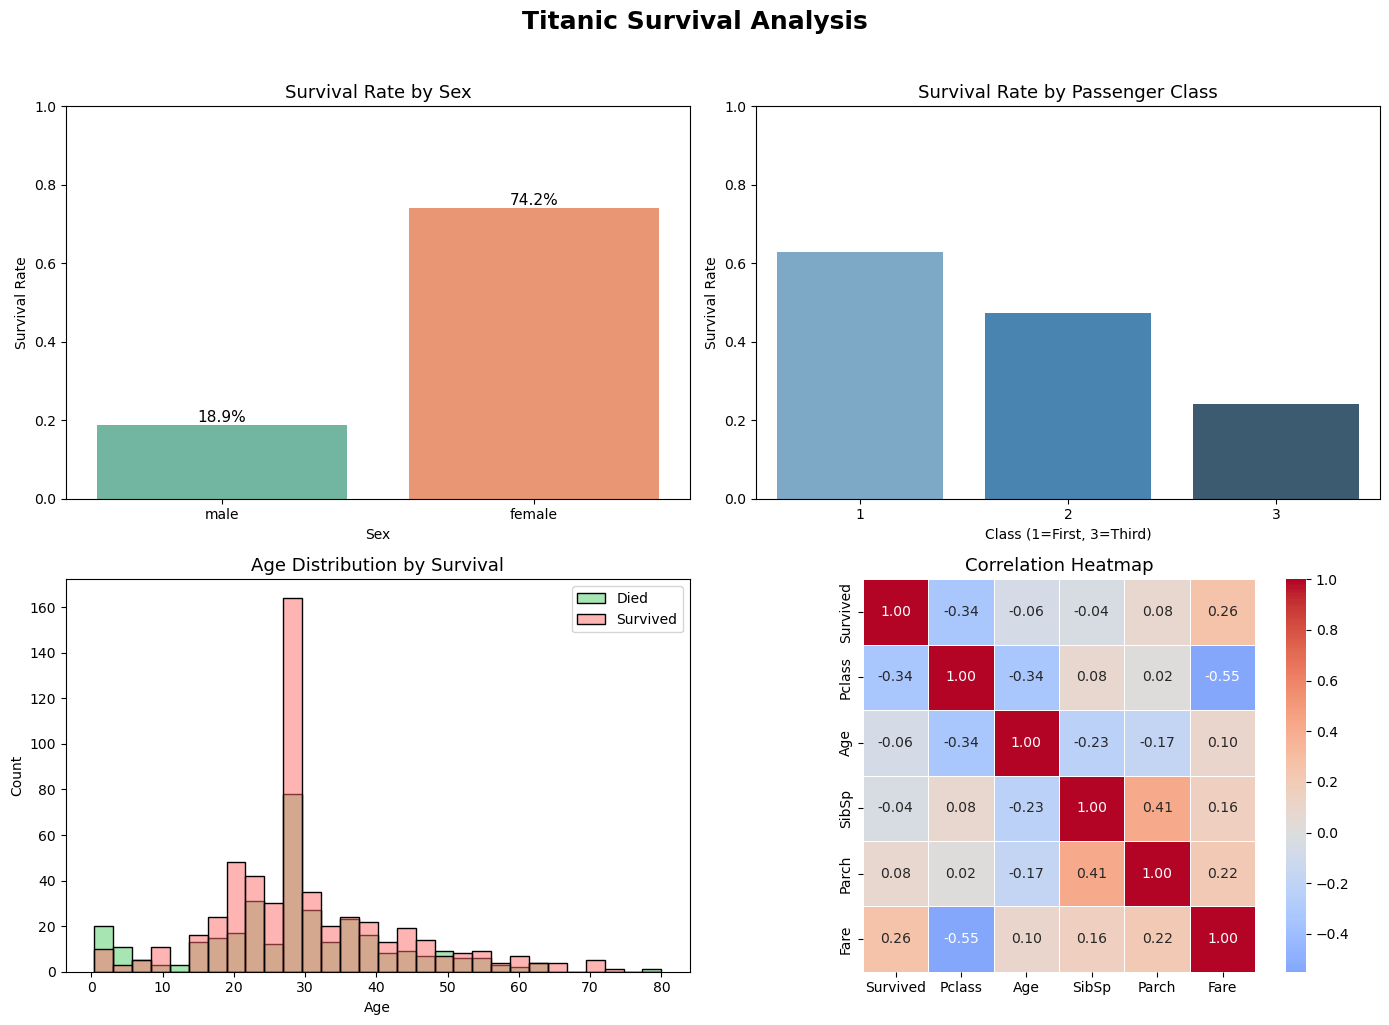

Chart saved as survival_analysis.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Titanic Survival Analysis", fontsize=18, fontweight='bold', y=1.02)

# --- Chart 1: Survival by Sex ---
sns.barplot(data=df_clean, x='Sex', y='Survived', 
            ax=axes[0,0], palette='Set2', errorbar=None)
axes[0,0].set_title('Survival Rate by Sex', fontsize=13)
axes[0,0].set_ylabel('Survival Rate')
axes[0,0].set_ylim(0, 1)
# Add percentage labels on bars
for p in axes[0,0].patches:
    axes[0,0].annotate(f'{p.get_height():.1%}', 
                       (p.get_x() + p.get_width()/2, p.get_height()),
                       ha='center', va='bottom', fontsize=11)

# --- Chart 2: Survival by Pclass ---
sns.barplot(data=df_clean, x='Pclass', y='Survived', 
            ax=axes[0,1], palette='Blues_d', errorbar=None)
axes[0,1].set_title('Survival Rate by Passenger Class', fontsize=13)
axes[0,1].set_ylabel('Survival Rate')
axes[0,1].set_ylim(0, 1)
axes[0,1].set_xlabel('Class (1=First, 3=Third)')

# --- Chart 3: Age Distribution by Survival ---
sns.histplot(data=df_clean, x='Age', hue='Survived', 
             bins=30, ax=axes[1,0], palette={0:'#ff6b6b', 1:'#51cf66'})
axes[1,0].set_title('Age Distribution by Survival', fontsize=13)
axes[1,0].legend(labels=['Died', 'Survived'])

# --- Chart 4: Correlation Heatmap ---
corr_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr = df_clean[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', 
            ax=axes[1,1], cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
axes[1,1].set_title('Correlation Heatmap', fontsize=13)

plt.tight_layout()
plt.savefig('survival_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as survival_analysis.png")

## Findings — Who Survived the Titanic, and Why?

The data reveals survival was shaped by three dominant factors: **gender, 
passenger class, and age**.

**Gender** was the strongest predictor — women survived at 74% vs men at 19%, 
directly reflecting the "women and children first" evacuation protocol enforced 
by the crew.

**Class** was equally decisive — 1st class passengers survived at 63%, 2nd class 
at 47%, and 3rd class at only 24%. This reflects both physical cabin location 
(lower decks for 3rd class, farther from lifeboats) and likely priority boarding 
access given to wealthier passengers.

**Age** had a modest effect — children showed slightly higher survival rates, 
while adult men fared worst. Fare correlates positively with survival, 
reinforcing the class signal.

**What I'd do next with more time:** Engineer a `FamilySize` feature 
(SibSp + Parch + 1), extract passenger titles from names (Mr/Mrs/Master), 
and train a baseline logistic regression to quantify each variable's 
independent contribution to survival probability.